# Práctica Evaluable - Unidad 3  
## Generador de Titulares con Miniature GPT

**Alumno:** Alberto Coca  
**Fecha:** 17 de febrero de 2026  

> Versión preparada para ejecutarse **en local** desde **Visual Studio Code + Jupyter**.

## Requisitos locales
Instala estas dependencias en tu entorno virtual antes de abrir el notebook:

```bash
pip install tensorflow keras numpy matplotlib gdown notebook ipykernel
```

Si dispones de GPU local y TensorFlow la detecta, el entrenamiento será más rápido.  
Si no tienes GPU, el notebook también funciona en CPU, aunque tardará más.

## Parte 1 — Preparación del entorno

En esta práctica se implementa un modelo Transformer pequeño inspirado en el tutorial de Keras **“Text generation with a miniature GPT”**, adaptado para generar **titulares en español** a partir de un corpus pequeño.

El objetivo es comprender a nivel de código:
- embeddings de token y posición
- atención causal
- bloque Transformer
- entrenamiento autoregresivo
- generación de texto con distintas temperaturas

In [1]:
import tensorflow as tf
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.21.0
GPU disponible: []


In [2]:
# Descargar dataset en local de forma robusta
import sys
import subprocess

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown

dataset_path = "titulares.txt"

if not os.path.exists(dataset_path):
    gdown.download(
        id="199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN",
        output=dataset_path,
        quiet=False
    )

print("Dataset disponible en:", os.path.abspath(dataset_path))

Dataset disponible en: c:\Users\alber\OneDrive\Escritorio\Escritorio\asignaturas2cuatri\aprendizajeautomatizado2\practicas\unidad3\titulares.txt


In [3]:
# Cargar texto
with open("titulares.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print("\nMuestra del corpus:")
print(text[:500])

Caracteres totales: 60438

Muestra del corpus:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


### Comentario

El corpus contiene **1.079 titulares** en español.  
Se trabaja con **tokenización a nivel de carácter**, lo que simplifica mucho la implementación y permite observar el flujo completo del modelo sin usar tokenizadores externos.

## Parte 2 — Tokenización a nivel de carácter

In [4]:
# Crear vocabulario
# Añadimos dos tokens especiales:
# - PAD para rellenar secuencias en generación
# - UNK para caracteres no vistos en el corpus
PAD_TOKEN = "§"
UNK_TOKEN = "¤"

vocab = sorted(set(text))
for special in [PAD_TOKEN, UNK_TOKEN]:
    if special not in vocab:
        vocab.append(special)

vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos (incluyendo PAD y UNK)")
print(vocab)

# Diccionarios de conversión
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

pad_idx = char_to_idx[PAD_TOKEN]
unk_idx = char_to_idx[UNK_TOKEN]

def encode(s):
    return [char_to_idx.get(c, unk_idx) for c in s]

def decode(ids, skip_special=True):
    chars = []
    for i in ids:
        ch = idx_to_char[i]
        if skip_special and ch in {PAD_TOKEN, UNK_TOKEN}:
            continue
        chars.append(ch)
    return "".join(chars)

# Tests
ejemplo = "Hola"
ids = encode(ejemplo)
print("Texto:", ejemplo)
print("Codificado:", ids)
print("Decodificado:", decode(ids))

ejemplo_corpus = text[:20]
ids_corpus = encode(ejemplo_corpus)
print("\nEjemplo tomado del corpus:")
print("Texto:", ejemplo_corpus)
print("Codificado:", ids_corpus)
print("Decodificado:", decode(ids_corpus))

Vocabulario: 35 caracteres únicos (incluyendo PAD y UNK)
['\n', ' ', '1', '2', '3', '4', '7', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '§', '¤']
Texto: Hola
Codificado: [34, 22, 19, 8]
Decodificado: ola

Ejemplo tomado del corpus:
Texto: nueva ley de energia
Codificado: [21, 28, 12, 29, 8, 1, 19, 12, 31, 1, 11, 12, 1, 12, 21, 12, 25, 14, 16, 8]
Decodificado: nueva ley de energia


### Reflexión

La tokenización por carácter tiene dos ventajas:
1. vocabulario pequeño
2. implementación muy transparente

La principal desventaja es que el modelo necesita aprender letras, sílabas y palabras desde cero, lo que hace más difícil la generación coherente.

## Parte 3 — Preparación de datos de entrenamiento

In [5]:
# Parámetros
SEQ_LENGTH = 80
BATCH_SIZE = 64
VAL_SPLIT = 0.1

tokens = np.array(encode(text), dtype=np.int32)

def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("\nPrimera secuencia X:")
print(decode(X[0]))
print("\nPrimera secuencia y:")
print(decode(y[0]))

Forma de X: (60358, 80)
Forma de y: (60358, 80)

Primera secuencia X:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatic

Primera secuencia y:
ueva ley de energia promete revolucionar el sector electrico
el cambio climatico


In [6]:
# Separación train / validation
num_samples = len(X)
split_idx = int(num_samples * (1 - VAL_SPLIT))

X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(10000, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for batch_x, batch_y in train_ds.take(1):
    print("Batch X:", batch_x.shape)
    print("Batch y:", batch_y.shape)

Train: (54322, 80) (54322, 80)
Validation: (6036, 80) (6036, 80)
Batch X: (64, 80)
Batch y: (64, 80)


### Comentario

El entrenamiento es **autoregresivo**.  
La entrada es una secuencia de caracteres y la salida es esa misma secuencia desplazada una posición a la derecha.  
Así, en cada paso, el modelo aprende a predecir el siguiente carácter.

## Parte 4 — Componentes del Transformer

In [7]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [8]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.key_dim = embed_dim // num_heads

        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=self.key_dim
        )

        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.int32)
        mask = tf.reshape(mask, (1, seq_len, seq_len))
        mult = tf.concat(
            [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)],
            axis=0
        )
        return tf.tile(mask, mult)

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        causal_mask = self.causal_attention_mask(batch_size, seq_len)

        attn_output = self.att(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask,
            training=training,
        )
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

### Explicación

- **TokenAndPositionEmbedding** suma embedding del carácter + embedding posicional.
- **TransformerBlock** implementa:
  - self-attention causal
  - residual + normalization
  - feed-forward network
  - residual + normalization

La máscara causal es esencial porque el modelo debe predecir el siguiente carácter sin ver el futuro.

## Parte 5 — Modelo completo

In [9]:
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    outputs = layers.Dense(vocab_size, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 80, 256)        │        29,440 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80, 35)         │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,146,851 (8.19 MB)

 Trainable params: 2,146,851 (8.19 MB)

 Non-trainable params: 0 (0.00 B)

### Comentario

La capa final proyecta la representación interna al tamaño del vocabulario y aplica softmax, generando una distribución de probabilidad sobre el siguiente carácter para cada posición.

## Parte 6 — Entrenamiento

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 153s 174ms/step - accuracy: 0.6968 - loss: 0.9556 - val_accuracy: 0.9317 - val_loss: 0.2485 - learning_rate: 0.0010
Epoch 2/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 144s 170ms/step - accuracy: 0.8973 - loss: 0.3164 - val_accuracy: 0.9336 - val_loss: 0.2724 - learning_rate: 0.0010
Epoch 3/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 147s 173ms/step - accuracy: 0.9295 - loss: 0.2141 - val_accuracy: 0.9340 - val_loss: 0.2740 - learning_rate: 0.0010
Epoch 4/30
849/849 ━━━━━━━━━━━━━━━━━━━━ 150s 177ms/step - accuracy: 0.9460 - loss: 0.1617 - val_accuracy: 0.9384 - val_loss: 0.2774 - learning_rate: 5.0000e-04


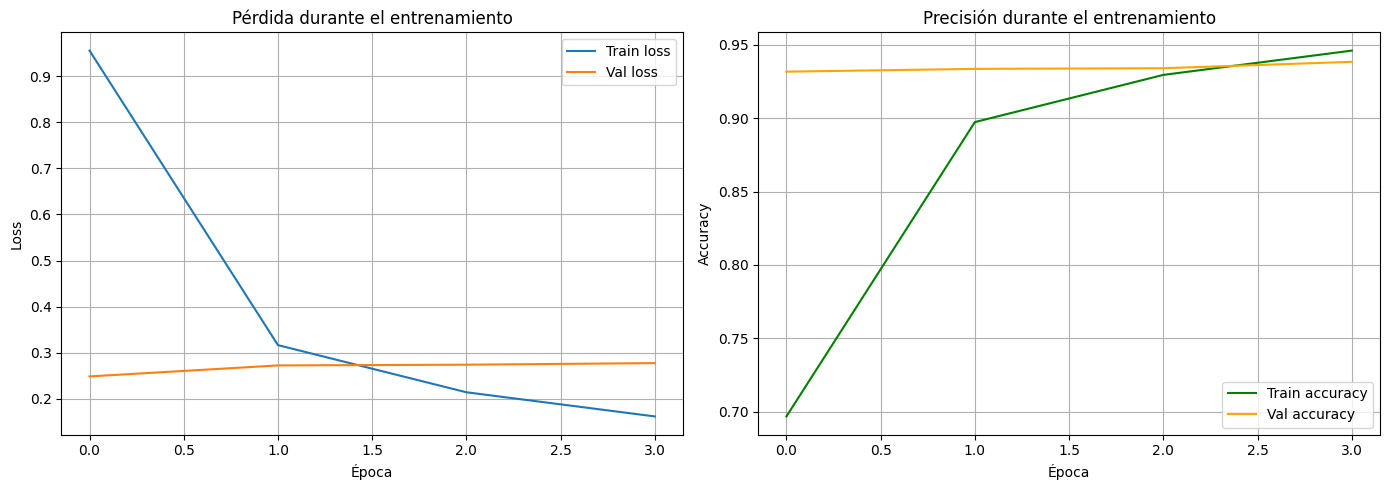

In [12]:
# Gráficas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Pérdida durante el entrenamiento")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Train accuracy", color="green")
axes[1].plot(history.history["val_accuracy"], label="Val accuracy", color="orange")
axes[1].set_title("Precisión durante el entrenamiento")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Análisis del entrenamiento

Las curvas de entrenamiento permiten comprobar si el modelo está aprendiendo realmente.
Lo esperable es:
- descenso gradual de la pérdida
- aumento de la precisión
- posible diferencia entre train y validation si aparece sobreajuste

Esto es importante para la rúbrica, ya que no basta con entrenar: también hay que **documentar y analizar** el proceso.

## Parte 7 — Generación de texto

In [13]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    generado = list(encode(inicio))

    for _ in range(longitud):
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq, dtype=np.int32)[np.newaxis, :]

        if input_seq.shape[1] < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - input_seq.shape[1]
            input_seq = np.pad(
                input_seq,
                ((0, 0), (pad_len, 0)),
                mode="constant",
                constant_values=pad_idx
            )

        preds = model.predict(input_seq, verbose=0)[0, -1, :]
        logits = np.log(preds + 1e-10) / max(temperatura, 1e-3)
        logits = logits - np.max(logits)
        probs = np.exp(logits) / np.sum(np.exp(logits))

        next_idx = np.random.choice(len(probs), p=probs)
        generado.append(next_idx)

        # Cortar si aparece salto de línea
        if idx_to_char[next_idx] == "\n":
            break

    return decode(generado)

In [14]:
print("=== Temperatura 0.5 ===")
print(generar_texto(model, "El gobierno ", temperatura=0.5))

print("\n=== Temperatura 1.0 ===")
print(generar_texto(model, "El gobierno ", temperatura=1.0))

print("\n=== Temperatura 1.5 ===")
print(generar_texto(model, "El gobierno ", temperatura=1.5))

=== Temperatura 0.5 ===
l gobierno espacial


=== Temperatura 1.0 ===
l gobierno la salud de los mares


=== Temperatura 1.5 ===
l gobierno efmprido de las estudiontes



In [15]:
inicios = ["La economía ", "Un nuevo ", "El presidente ", "Argentina ", "Se espera "]

for inicio in inicios:
    print(f"Inicio: '{inicio}'")
    print("  →", generar_texto(model, inicio, temperatura=0.8))
    print()

Inicio: 'La economía '
  → a economa lanarel paradizaje


Inicio: 'Un nuevo '
  → n nuevo labilidad y la justicia social


Inicio: 'El presidente '
  → l presidente la socidad y el bienestar emocional


Inicio: 'Argentina '
  → rgentina el bienestar emocional


Inicio: 'Se espera '
  → e espera el bienestar emocional




## Parte 8 — Análisis y reflexión final

### Patrones que puede capturar el modelo
Después del entrenamiento, el modelo debería aprender:
- estructuras típicas de titulares periodísticos
- combinaciones frecuentes de palabras
- ritmo y formato de titulares
- uso habitual de mayúsculas, acentos y signos

### Limitaciones
También hay limitaciones claras:
- el corpus es pequeño
- la tokenización por carácter es más difícil que subword
- puede generar palabras inexistentes
- con temperaturas altas, la coherencia disminuye

### Efecto de la temperatura
- **0.5:** más conservador y coherente
- **1.0:** equilibrio razonable
- **1.5:** más creatividad, pero más errores

### Conclusión personal
Esta práctica demuestra de forma práctica cómo funciona un Transformer generativo desde cero.
Aunque el modelo es pequeño, sí permite observar claramente los principios fundamentales: embeddings posicionales, atención causal, entrenamiento autoregresivo y generación paso a paso.

## Recomendación final antes de entregar

Ejecuta este notebook **de principio a fin** en Visual Studio Code o Jupyter local y guarda el archivo con:
- outputs visibles
- gráficas visibles
- ejemplos generados visibles

**Nombre recomendado del archivo:** `Coca_Alberto_U3_Practica_local.ipynb`

## Notas de ejecución en local

Si aparece algún error al descargar el dataset o al detectar GPU:
- comprueba que el entorno virtual activo en VS Code es el correcto
- reinicia el kernel tras instalar paquetes
- ejecuta las celdas en orden, de arriba a abajo

Si el entrenamiento tarda demasiado en CPU, puedes:
- reducir `NUM_BLOCKS` de 4 a 2
- reducir `EMBED_DIM` de 256 a 128
- bajar `epochs` de 30 a 10–15 para una prueba rápida